In [21]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [22]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [23]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [24]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    # Tells us what intial state for object is
    def initial_state(self) -> Tuple[int, int]:
        return self.start

    # asks if object's currect state is the goal
    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    # checks if state is outside of given bounds by checking if its rows and columsn are less than the given state rows and columns
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    # Checks if you can move to a given state's co-ord by making sure that that ordinate is not block with a 1 and is indeed 0/free
    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.

        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action in MOVES:
            #       a. Compute the neighbour cell.
            dr, dc = MOVES[action]
            neig_row = state[0] + dr
            neig_col = state[1] + dc
            neig_coord = (neig_row, neig_col)
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        if (self.in_bounds(neig_coord) == True) and (self.is_free(neig_coord) == True):
            #       d. If valid, add the action name to legal_actions.
            legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        new_row = state[0] + dr
        new_col = state[1] + dc
        new_coord = (new_row, new_col)
        return new_coord
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [26]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [27]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [28]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

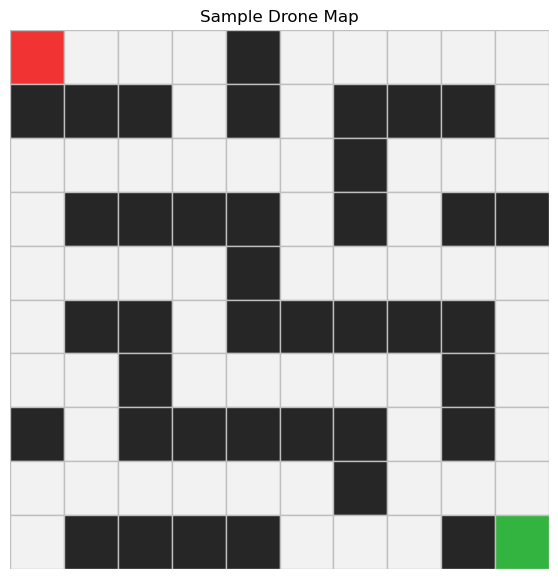

In [29]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).

        # Pseudocode:
        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
            #     s_prime <- problem.RESULT(s, action)
            s_prime = problem.result(s, action)
            #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

        raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.

        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(status="success", node=initial_node)
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])

        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}
        # 5. While frontier is not empty:
        while len(frontier) > 0:
            #       a. pop from the LEFT of the deque.
            node = frontier.popleft()
            #       b. increment nodes_expanded.
            problem.nodes_expanded += 1
            #       c. expand the node.
            #       d. for each child:
            for child in self.expand(problem, node):
                s = child.state
                #            i. if child is goal, return success.
                if problem.is_goal(s):
                    return SearchResult(status="success", node=child)
                #           ii. if child.state is not in reached:
                if s not in reached:
                    #                  add child.state to reached.
                    reached.add(child.state())
                    #                  append child to frontier.
                    frontier.append(child)
            #       e. update max_frontier_size.
            problem.max_frontier_size = max(problem.max_frontier_size, len(frontier))
        # 6. Return failure if no solution is found.
        return None

        raise NotImplementedError("Complete BreadthFirstSearch.search")

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        # TODO 7:
        # Implement DFS graph search using a stack.
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(status="success", node=initial_node)
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        # 4. Use a reached set.
        reached_set = {problem.initial_state()}
        while len(frontier) > 0:
            # 5. While frontier is not empty:
            #       a. pop from the end of the list.
            node = frontier.pop()
            #       b. increment nodes_expanded.
            problem.nodes_expanded += 1
            #       c. expand the node.
            #       d. add unreached children to the stack.
            for child in self.expand(problem, node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(status="success", node=child)

                if child.state not in reached_set:
                    reached_set.add(s)
                    frontier.append(child)
            #       e. update max_frontier_size.
            problem.max_frontier_size = max(problem.max_frontier_size, len(frontier))
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        raise NotImplementedError("Complete DepthFirstSearch.search")

In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return SearchAlgorithm(node=node, show_results="success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")